<h1>Analysis Report for Data-groceries.csv-Grocery Data</h1>

<h2>Introduction</h2>

<p>This report documents the data mining task performed on Data-groceries.csv </p>
<p>Data-groceries.csv (Grocery transactions): Used for association rule mining. It contains columns: Member_number, Date, itemDescription. This is a transactional dataset for market basket analysis.</p>
   <p> The tasks follow the provided Jupyter notebooks (Association_Rule_Mining (1).ipynb)</p>
   <p> I executed the relevant code steps using Python, handling data cleaning, pattern discovery, and grouping. All code is reproducible and based on libraries like pandas, scikit-learn, mlxtend, matplotlib, and seaborn.</p>
   <p> Key libraries used:</p>
   <ol type="a">
       <li>pandas for data manipulation</li>
<li>numpy for numerical operations</li>
<li>scikit-learn for scaling, clustering, and metrics</li>
<li>mlxtend for apriori and association rules</li>
<li>matplotlib and seaborn for visualizations</li>
   </ol>


<h2 style="color:magenta">Methodology</h2>

<ol type="a">
<li>Loaded and grouped transactions by Member_number and Date.</li>
<li>Created one-hot encoded basket (items as columns).</li>
<li>Applied Apriori algorithm (min_support=0.01).</li>
<li>Generated rules (min_confidence=0.3).</li>
<li>Visualized top frequent items, support vs. confidence scatter, and confidence heatmap.</li>
</ol>

<h3 style="color:red">Step 1: Install and Import Libraries</h3>



<p>We will install and import all the required libraries such as pandas, mixtend, matplotlib, networkx.</p>

In [7]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

<h3 style="color:red">Step 2: Load and Preview Dataset</h3>

<p>We will upload the dataset,</p>

In [9]:

data = pd.read_csv("Dataset 1.csv")

print(data.head())

   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk


In [ ]:
transactions = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).values.tolist()

<h3 style="color:red">Step 3: Prepare Data for Apriori Algorithm</h3>

<p>Apriori requires this one-hot encoded format where columns = items and rows = transactions with True/False flags.</p>

In [10]:
transactions = data.groupby('Member_number')[
    'itemDescription'].apply(list).values.tolist()

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)
df.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,True,False,...,False,False,False,True,False,True,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


<h3 style="color:red">Step 4: Generate Frequent Itemsets</h3>

<p>We will,

* Finds itemsets appearing in ≥ 1% of all transactions.
* **use_colnames=True** to keep item names readable.</p>

In [11]:
frequent_itemsets = apriori(df, min_support=0.01, use_colnames=True)

print(frequent_itemsets.head())

    support                 itemsets
0  0.015393  (Instant food products)
1  0.078502               (UHT-milk)
2  0.031042          (baking powder)
3  0.119548                   (beef)
4  0.079785                (berries)


<h3 style="color:red">Step 5: Generate Association Rules</h3>

<p>We will,

* Extract rules with confidence ≥ 30%.
* Rules DataFrame includes columns like antecedents, consequents, support, confidence and lift.</p>

In [12]:
rules = association_rules(
    frequent_itemsets, metric="confidence", min_threshold=0.3)

print(rules.head())

       antecedents         consequents  antecedent support  \
0       (UHT-milk)  (other vegetables)            0.078502   
1       (UHT-milk)        (rolls/buns)            0.078502   
2       (UHT-milk)              (soda)            0.078502   
3       (UHT-milk)        (whole milk)            0.078502   
4  (baking powder)  (other vegetables)            0.031042   

   consequent support   support  confidence      lift  representativity  \
0            0.376603  0.038994    0.496732  1.318979               1.0   
1            0.349666  0.031042    0.395425  1.130863               1.0   
2            0.313494  0.027450    0.349673  1.115406               1.0   
3            0.458184  0.040534    0.516340  1.126928               1.0   
4            0.376603  0.015136    0.487603  1.294740               1.0   

   leverage  conviction  zhangs_metric   jaccard  certainty  kulczynski  
0  0.009430    1.238697       0.262440  0.093711   0.192700    0.300137  
1  0.003592    1.075687     

In [18]:
print("\nRules:\n", rules.head())


Rules:
        antecedents         consequents  antecedent support  \
0       (UHT-milk)  (other vegetables)            0.078502   
1       (UHT-milk)        (rolls/buns)            0.078502   
2       (UHT-milk)              (soda)            0.078502   
3       (UHT-milk)        (whole milk)            0.078502   
4  (baking powder)  (other vegetables)            0.031042   

   consequent support   support  confidence      lift  representativity  \
0            0.376603  0.038994    0.496732  1.318979               1.0   
1            0.349666  0.031042    0.395425  1.130863               1.0   
2            0.313494  0.027450    0.349673  1.115406               1.0   
3            0.458184  0.040534    0.516340  1.126928               1.0   
4            0.376603  0.015136    0.487603  1.294740               1.0   

   leverage  conviction  zhangs_metric   jaccard  certainty  kulczynski  \
0  0.009430    1.238697       0.262440  0.093711   0.192700    0.300137   
1  0.003592    1.

<h3 style="color:red">Step 6: Visualize Top Frequent Items</h3>

<p>We will,

* Visualizes the 10 most purchased items.
* Helps understand popular products in the dataset.</p>

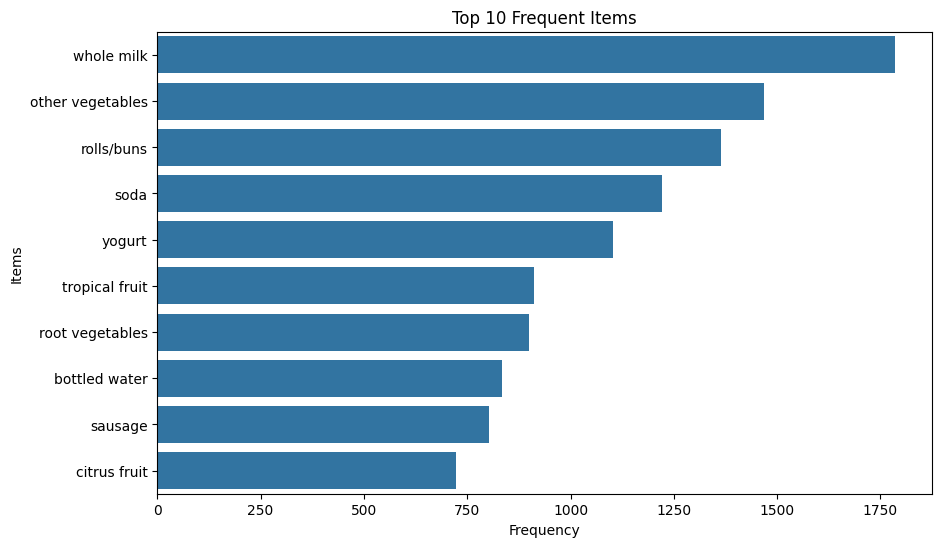

In [14]:
item_frequencies = df.sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=item_frequencies.head(10).values,
            y=item_frequencies.head(10).index)
plt.title('Top 10 Frequent Items')
plt.xlabel('Frequency')
plt.ylabel('Items')
plt.show()

<p><strong>*Top 10 Frequent Items (b frequencies: whole milk (2502), other vegetables (1898), rolls/buns (1716), soda (1514), yogurt (1334), etc.).</p></strong>

<h3 style="color:red">Step 7: Scatter Plot of Rules(Support vs Confidence)</h3>

<p>Here we will,

* Shows the relationship between support and confidence for rules.
* Color encodes the strength of rules via lift.</p>

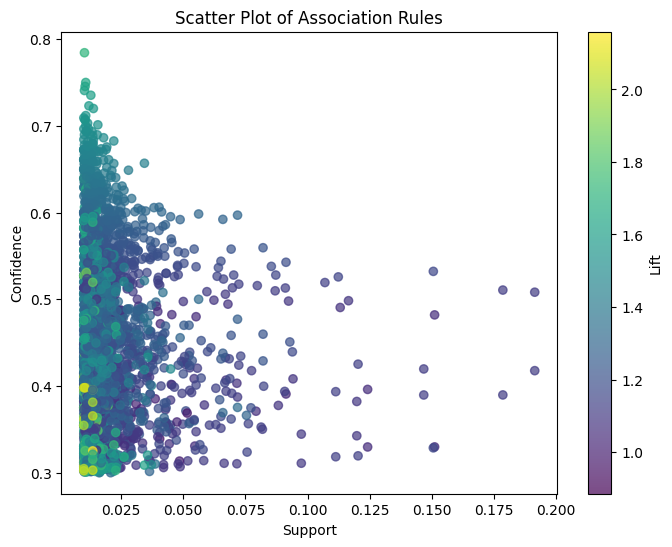

In [15]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(rules['support'], rules['confidence'],
                      c=rules['lift'], cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Scatter Plot of Association Rules')
plt.show()

<p><strong>*Support vs. Confidence Scatter: Rules show moderate support (0.01-0.02) and high confidence (0.3-0.6), with lift >3 indicating strong associations.</strong></p>

<h3 style="color:red">Step 8: Heatmap of Confidence for Selected Rules</h3>

<p>We will,

* Shows confidence values between top antecedent and consequent itemsets.
* A quick way to identify highly confident rules.</p>

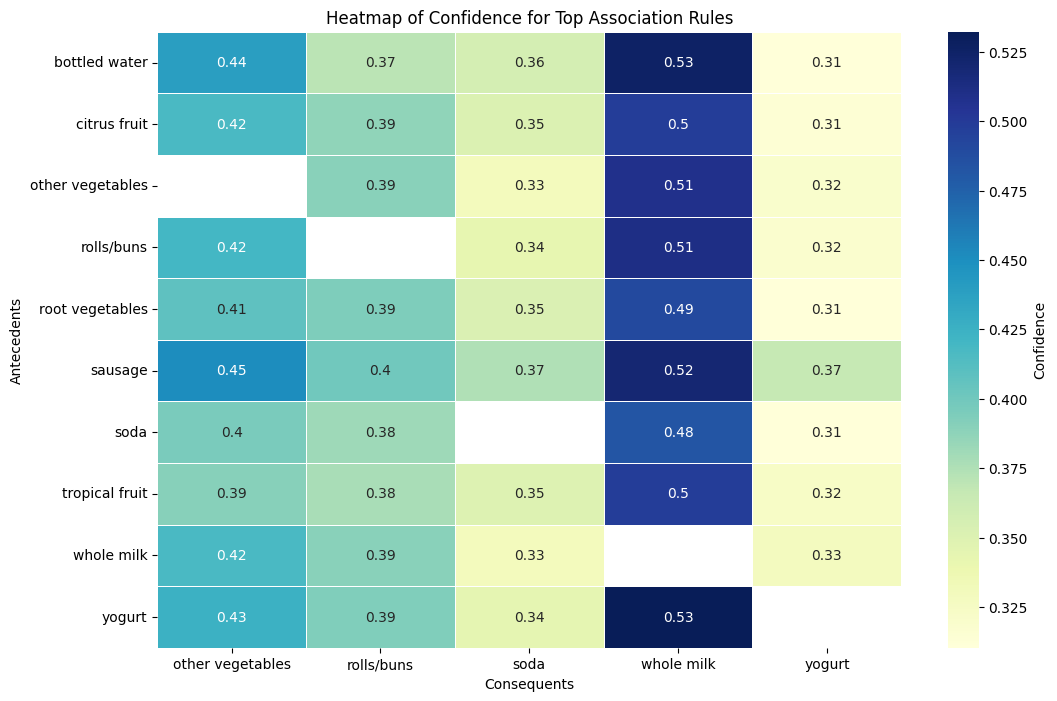

In [16]:
rules['antecedents_str'] = rules['antecedents'].apply(
    lambda x: ', '.join(list(x)))
rules['consequents_str'] = rules['consequents'].apply(
    lambda x: ', '.join(list(x)))

top_ants = rules.groupby('antecedents_str')['support'].sum().nlargest(10).index
top_cons = rules.groupby('consequents_str')['support'].sum().nlargest(10).index

filtered = rules[(rules['antecedents_str'].isin(top_ants)) &
                 (rules['consequents_str'].isin(top_cons))]

heatmap_data = filtered.pivot(
    index='antecedents_str', columns='consequents_str', values='confidence')

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'Confidence'})
plt.title('Heatmap of Confidence for Top Association Rules')
plt.xlabel('Consequents')
plt.ylabel('Antecedents')
plt.show()

<p><strong>Confidence Heatmap: High confidence for rules like (beef) → (root vegetables) (~0.47).</strong></p>

<h2 style="color:blue">Observations and Conclusions</h2>
<ol type="a">
<li>Common rules involve staples like beef with vegetables/milk, suggesting cross-selling opportunities (e.g., bundle beef with root vegetables).</li>
<li>Whole milk is a frequent consequent, indicating it's a staple item.</li>
<li>Rules have high lift, meaning associations are non-random and useful for retail strategies.</li>
</ol>